### Exploring the exact features to use to fit the models prediction behaviors

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import duckdb 
import json

In [ ]:
df = duckdb.query("SELECT * FROM '../outputs/training_data.parquet'").to_df()

FEATURES = [
    'zhvi_yoy_smooth', 'zhvi_mom_3m', 'zhvi_volatility_6m',
    'zori_yoy_smooth', 'zori_mom_3m', 'zori_volatility_6m',
    'unemployment_rate', 'unemployment_3m_delta',
    'jobs_3m_pct', 'jobs_yoy_pct', 'wages_yoy_pct',
    'permits_yoy_pct',
    'mortgage_rate_3m_delta', 'mortgage_rate_12m_delta',
    'mortgage_rate_volatility_6m', 'cpi_yoy_pct',
    'price_to_income_ratio', 'piti_rate_pressure',
    'rent_to_income_ratio', 'piti_shock'
]
TARGET = 'hpa_12m_forward'

In [36]:
# Drop rows with any null in features or target
df_clean = df[FEATURES + [TARGET, 'city', 'month']].dropna()
print(f"Rows after dropping nulls: {len(df_clean):,}")
print(f"Dropped: {len(df) - len(df_clean):,} rows")
X = df_clean[FEATURES]
y = df_clean[TARGET]

Rows after dropping nulls: 2,533
Dropped: 21 rows


In [38]:
# Mutual Information Scores
# Non-linear signal detection — complements correlation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mi_scores = mutual_info_regression(X_scaled, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': FEATURES,
    'mutual_info': mi_scores,
    'abs_correlation': X.corrwith(y).abs().values
}).sort_values('mutual_info', ascending=False).reset_index(drop=True)

print("\nFeature Signal Ranking:")
mi_df


Feature Signal Ranking:


,feature,mutual_info,abs_correlation
0,cpi_yoy_pct,0.620182,0.337601
1,price_to_income_ratio,0.596442,0.273622
2,mortgage_rate_volatility_6m,0.594952,0.508492
3,rent_to_income_ratio,0.469666,0.259822
4,mortgage_rate_3m_delta,0.468986,0.256827
5,jobs_yoy_pct,0.460852,0.292600
6,piti_to_income_ratio,0.447455,0.469120
7,unemployment_rate,0.431725,0.473129
8,mortgage_rate_12m_delta,0.428398,0.462517
9,unemployment_3m_delta,0.387354,0.050682


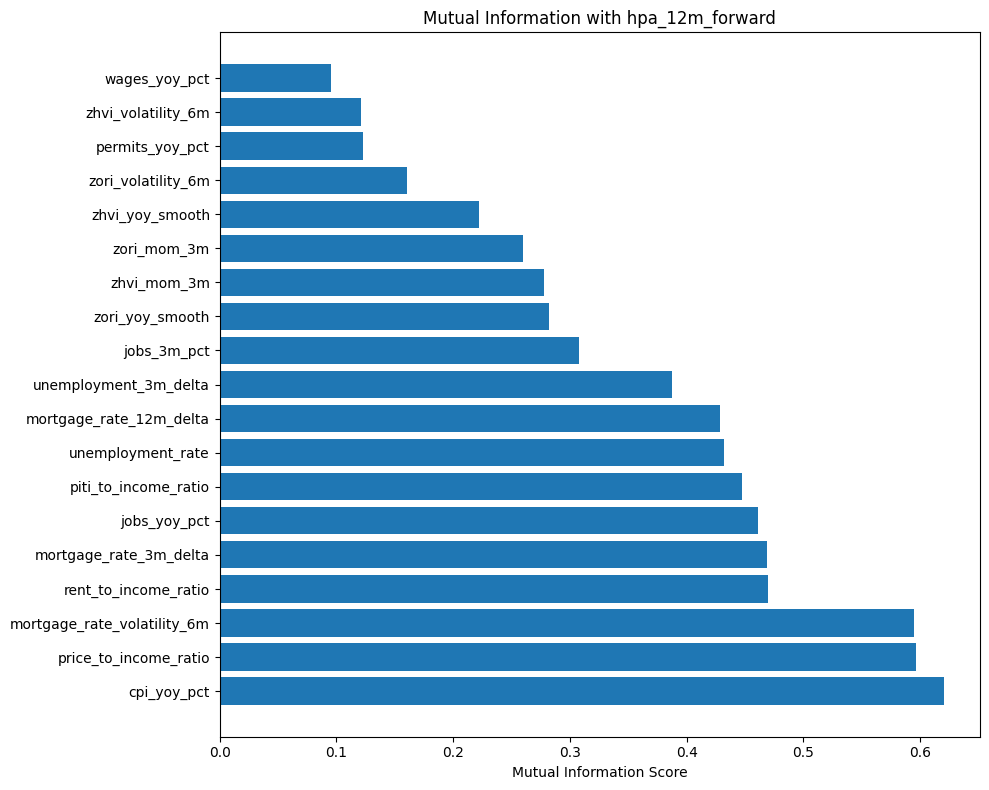

In [39]:
plt.figure(figsize=(10, 8))
plt.barh(mi_df['feature'], mi_df['mutual_info'])
plt.title('Mutual Information with hpa_12m_forward')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

In [ ]:
# Identify Low Signal Features
# Drop if BOTH mutual info AND correlation are low

LOW_MI_THRESHOLD = 0.01
LOW_CORR_THRESHOLD = 0.05

low_mi   = set(mi_df[mi_df['mutual_info'] < LOW_MI_THRESHOLD  ]['feature'])
low_corr = set(mi_df[mi_df['abs_correlation'] < LOW_CORR_THRESHOLD]['feature'])

# Only drop if BOTH are low — conservative approach
candidates_to_drop = low_mi & low_corr

print(f"\nLow MI only: {low_mi}")
print(f"Low correlation only: {low_corr}")
print(f"Drop candidates (both low): {candidates_to_drop}")


Low MI only: set()
Low correlation only: {'zori_yoy_smooth', 'jobs_3m_pct'}
Drop candidates (both low): set()


In [41]:
# Multicollinearity Analysis
# Ridge handles collinearity but knowing pairs helps interpret coefficients
corr_matrix = X.corr().abs()

# Extract upper triangle pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'correlation'})
    .query('correlation > 0.70')
    .sort_values('correlation', ascending=False)
)

print("\nHighly correlated pairs (>0.70):")
high_corr_pairs


Highly correlated pairs (>0.70):


,feature_a,feature_b,correlation
105,unemployment_3m_delta,jobs_3m_pct,0.952281
168,price_to_income_ratio,piti_to_income_ratio,0.918822
157,mortgage_rate_12m_delta,cpi_yoy_pct,0.791832
2,zhvi_yoy_smooth,zori_yoy_smooth,0.755036
156,mortgage_rate_12m_delta,mortgage_rate_volatility_6m,0.749968
170,piti_to_income_ratio,rent_to_income_ratio,0.722895


In [42]:
# VIF Check (Variance Inflation Factor) VIF > 10 = serious multicollinearity
vif_data = pd.DataFrame()
vif_data['feature'] = FEATURES
vif_data['VIF'] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF Scores (>10 = problematic for OLS, Ridge handles it):")
vif_data


VIF Scores (>10 = problematic for OLS, Ridge handles it):


,feature,VIF
17,piti_to_income_ratio,19.989077
8,jobs_3m_pct,13.838441
16,price_to_income_ratio,13.662735
7,unemployment_3m_delta,13.432883
15,cpi_yoy_pct,9.307972
13,mortgage_rate_12m_delta,7.815717
14,mortgage_rate_volatility_6m,4.556720
9,jobs_yoy_pct,4.535013
0,zhvi_yoy_smooth,4.120098
3,zori_yoy_smooth,3.859540


In [44]:
FEATURES_TO_DROP = ['jobs_3m_pct', 'wages_yoy_pct','piti_to_income_ratio']

FEATURES_FINAL = [f for f in FEATURES if f not in FEATURES_TO_DROP] 

reasoning = {
    'dropped': {
        'jobs_3m_pct':  'VIF=13.9, corr=0.95 with unemployment_3m_delta, MI lower (0.31 vs 0.39)',
        'wages_yoy_pct': 'Weakest signal: MI=0.096, corr=0.077 — both below threshold',
        'piti_to_income_ratio' : 'Strongly correlated to price_to_income_ratio but worse in both VIF and MI metrics so its less ideal for prediction model though it is more economically accurate.'
    },
    'kept_despite_high_vif': {
        'price_to_income_ratio':    'MI=0.60, strong nonlinear signal',
        'mortgage_to_income_ratio': 'MI=0.46, measures payment burden not static affordability',
        'unemployment_3m_delta':    'VIF drops after removing jobs_3m_pct'
    },
    'nonlinear_signal_flags': {
        'cpi_yoy_pct':           'MI=0.62 vs corr=0.34 — Ridge underweights this',
        'price_to_income_ratio': 'MI=0.60 vs corr=0.27 — Ridge underweights this'
    }
}

with open("../outputs/features_final.json", "w") as f:
    json.dump({'features': FEATURES_FINAL, 'reasoning': reasoning}, f, indent=2)

print(f"Final feature count: {len(FEATURES_FINAL)}")

Final feature count: 16
